# <span style="color: rgba(230, 0, 126, 1);"> DESAFÍO 3 - ANGÉLICA</span> #

## <span style="color: rgba(230, 0, 126, 1);"> Analistas de Finanzas y Riesgo Creditício </span> ##


In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error, roc_auc_score
from sklearn.preprocessing import LabelEncoder


In [34]:
dfA = pd.read_csv(
    r"C:\Users\mange\OneDrive\Cursos\Analisis de datos\Simulador\ProjecteData\Equip_18\Data\101125_dataset.csv",
    sep=';'
)
dfA.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,26176.000000,26176.000000,26176.000000,26176.000000,26176.000000,26176.000000,26176.000000,26176.000000
mean,13169.140434,41.319873,1529.098143,15.660758,370.574305,2.525902,51.324878,0.839204
std,7642.999558,11.926148,3302.237918,8.449347,347.622291,2.789066,109.572055,2.316192
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,6544.750000,32.000000,123.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,13088.500000,39.000000,553.000000,15.000000,253.000000,2.000000,-1.000000,0.000000
75%,19843.250000,49.000000,1711.000000,22.000000,494.000000,3.000000,9.000000,1.000000
max,26387.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [35]:

dfA = dfA.copy()
dfA = dfA.dropna(subset=['balance', 'default'])            
dfA['default_num'] = (dfA['default'].astype(str).str.lower() == 'yes').astype(int)


### <span style="color: rgba(230, 0, 126, 1);"> Regresión logistica binaria </span> ###

In [36]:
#Reviso cantidad de clientes en mora y la proporción
counts = dfA['default_num'].value_counts().sort_index()
props = dfA['default_num'].value_counts(normalize=True).sort_index()
print("Conteos (0=no, 1=yes):\n", counts)
print("\nProporciones (0=no, 1=yes):\n", props)


Conteos (0=no, 1=yes):
 default_num
0    25782
1      394
Name: count, dtype: int64

Proporciones (0=no, 1=yes):
 default_num
0    0.984948
1    0.015052
Name: proportion, dtype: float64


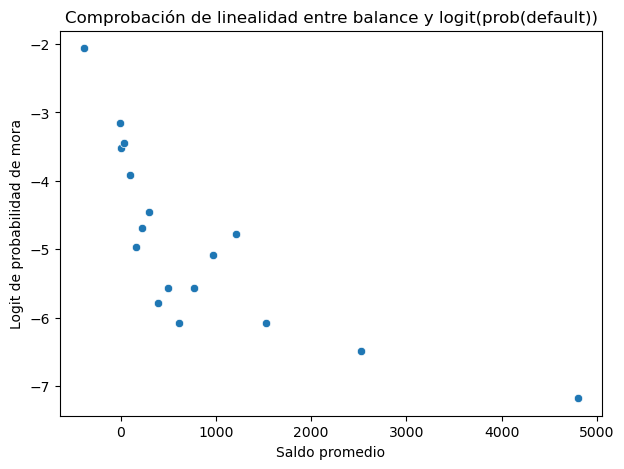

In [37]:
# Compruebo si hay linealidad entre las variables 
dfA['balance_bin'] = pd.qcut(dfA['balance'], q=20, duplicates='drop')

# Calcular la tasa de mora promedio por grupo de saldo
mean_balance = dfA.groupby('balance_bin')['balance'].mean()
mean_default = dfA.groupby('balance_bin')['default_num'].mean()

# Calcular el logit (log odds) de la probabilidad de mora
logit = np.log(mean_default / (1 - mean_default))

# Crear un DataFrame para visualizar la relación
linearity_df = pd.DataFrame({
    'mean_balance': mean_balance,
    'logit_default': logit
})

# Graficar
plt.figure(figsize=(7,5))
sns.scatterplot(x='mean_balance', y='logit_default', data=linearity_df)
sns.regplot(x='mean_balance', y='logit_default', data=linearity_df, ci=None, scatter=False, color='red')
plt.title('Comprobación de linealidad entre balance y logit(prob(default))')
plt.xlabel('Saldo promedio')
plt.ylabel('Logit de probabilidad de mora')
plt.show()


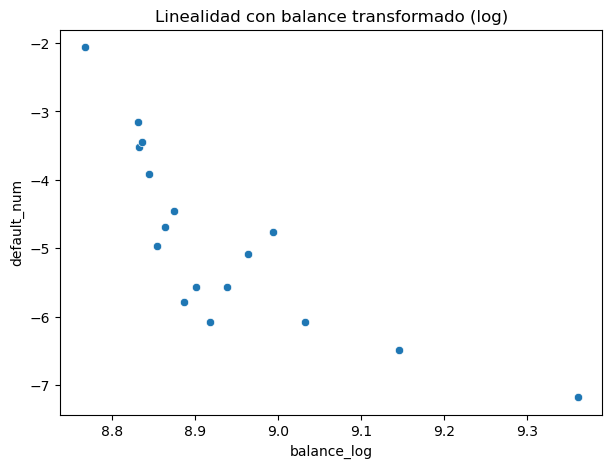

In [38]:
#como no veo linealidad en la grafica anterior, convierto a log
dfA['balance_log'] = np.log(dfA['balance'] - dfA['balance'].min() + 1)
dfA['balance_log_bin'] = pd.qcut(dfA['balance_log'], q=20, duplicates='drop')
mean_balance_log = dfA.groupby('balance_log_bin')['balance_log'].mean()
mean_default = dfA.groupby('balance_log_bin')['default_num'].mean()
logit = np.log(mean_default / (1 - mean_default))

plt.figure(figsize=(7,5))
sns.scatterplot(x=mean_balance_log, y=logit)
sns.regplot(x=mean_balance_log, y=logit, ci=None, scatter=False, color='red')
plt.title('Linealidad con balance transformado (log)')
plt.show()


In [39]:
#saco los coeficientes para ver que umbral da

X = dfA[['balance']]  # sin log
y = dfA['default_num']

model = LogisticRegression()
model.fit(X, y)

coef = model.coef_[0][0]
intercept = model.intercept_[0]

balance_umbral = -intercept / coef
print(balance_umbral)
#el umbral da negativo por lo que se comprueba que la reg logistica binaria no tiene sentido en estos datos al estar tan desbalanceados

-1650.5130013542207


### <span style="color: rgba(230, 0, 126, 1);"> Analisis con Deciles </span> ###

In [40]:
# Creo deciles del saldo
dfA['decil'] = pd.qcut(dfA['balance'], 10)

# Calcular tasa de mora por decil
tabla_deciles = dfA.groupby('decil')['default_num'].mean().reset_index()
tabla_deciles['Tasa mora (%)'] = (tabla_deciles['default_num'] * 100).round(2)
print(tabla_deciles)

tabla_deciles.to_csv("tasa_mora_por_decil.csv", index=False)
print("Archivo CSV de deciles creado con éxito!")

               decil  default_num  Tasa mora (%)
0   (-6847.001, 0.0]     0.068633           6.86
1        (0.0, 62.0]     0.030287           3.03
2      (62.0, 191.5]     0.013178           1.32
3     (191.5, 337.0]     0.010309           1.03
4     (337.0, 553.0]     0.003438           0.34
5     (553.0, 870.0]     0.003048           0.30
6    (870.0, 1349.0]     0.007282           0.73
7   (1349.0, 2206.0]     0.001146           0.11
8   (2206.0, 3871.0]     0.000764           0.08
9  (3871.0, 81204.0]     0.000382           0.04
Archivo CSV de deciles creado con éxito!


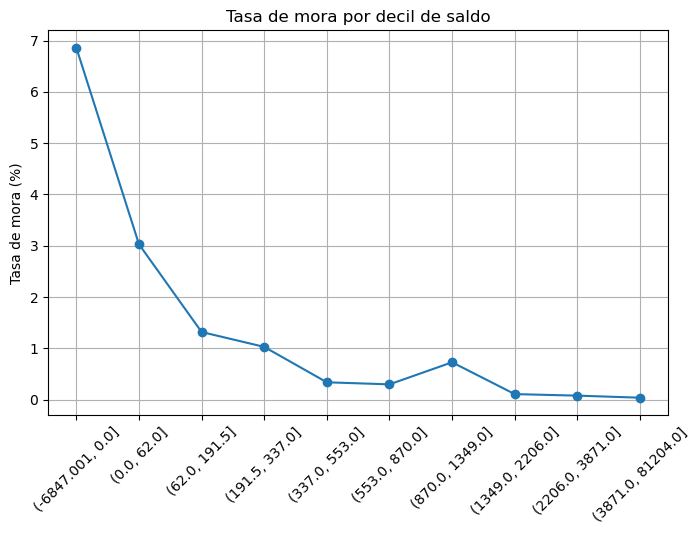

In [41]:
#grafica con Deciles
plt.figure(figsize=(8,5))
plt.plot(tabla_deciles['decil'].astype(str), tabla_deciles['Tasa mora (%)'], marker='o')
plt.xticks(rotation=45)
plt.ylabel('Tasa de mora (%)')
plt.title('Tasa de mora por decil de saldo')
plt.grid(True)
plt.show()


### <span style="color: rgba(230, 0, 126, 1);"> Random Forest Classifier</span> ###

In [ ]:
#defino variables
X = dfA[['balance']]
y = dfA['default_num']

#divido en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

rf = RandomForestClassifier(random_state=42)

param_grid = {'max_depth': [3,5,7], 'n_estimators':[100,200]}
grid = GridSearchCV(rf, param_grid, cv=3)
grid.fit(X_train, y_train)

# Mejor modelo
mejor_rf = grid.best_estimator_

# Predicciones
y_pred = mejor_rf.predict(X_test)
y_prob = mejor_rf.predict_proba(X_test)[:,1]  # probabilidad de default

# Compruebo calidad del modelo
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC AUC:", roc_auc)


Accuracy: 0.9856356968215159
ROC AUC: 0.9121570318961952


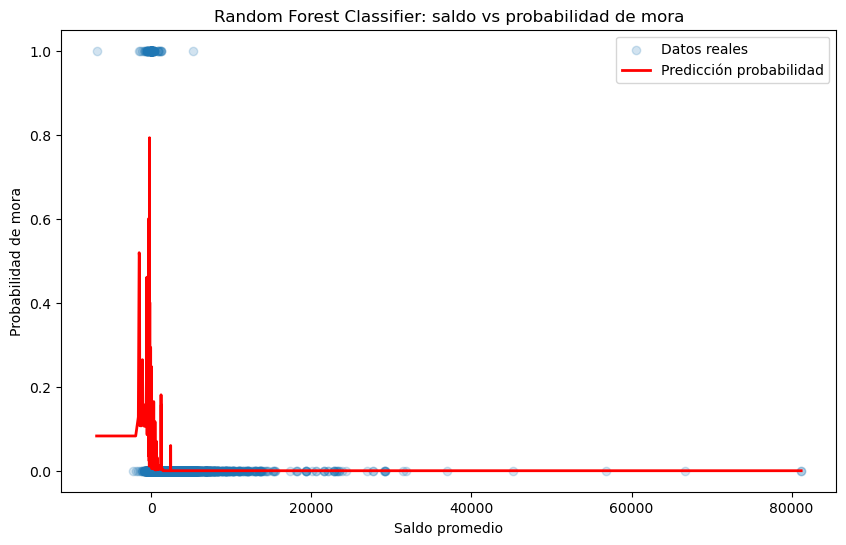

In [43]:
# Ordeno datos 
X_plot = X_test.sort_values('balance')
y_prob_plot = mejor_rf.predict_proba(X_plot)[:,1]

#grafico
plt.figure(figsize=(10,6))
plt.scatter(X_test['balance'], y_test, alpha=0.2, label='Datos reales')
plt.plot(X_plot['balance'], y_prob_plot, color='red', linewidth=2, label='Predicción probabilidad')
plt.xlabel("Saldo promedio")
plt.ylabel("Probabilidad de mora")
plt.title("Random Forest Classifier: saldo vs probabilidad de mora")
plt.legend()
plt.show()


In [44]:
# Filtro saldos bajos para hacer un zoom en la grafica
X_low = X_test[X_test['balance'] <= 2000]
y_low = y_test.loc[X_low.index]

# Probabilidades para este subconjunto
y_prob_low = mejor_rf.predict_proba(X_low)[:,1]


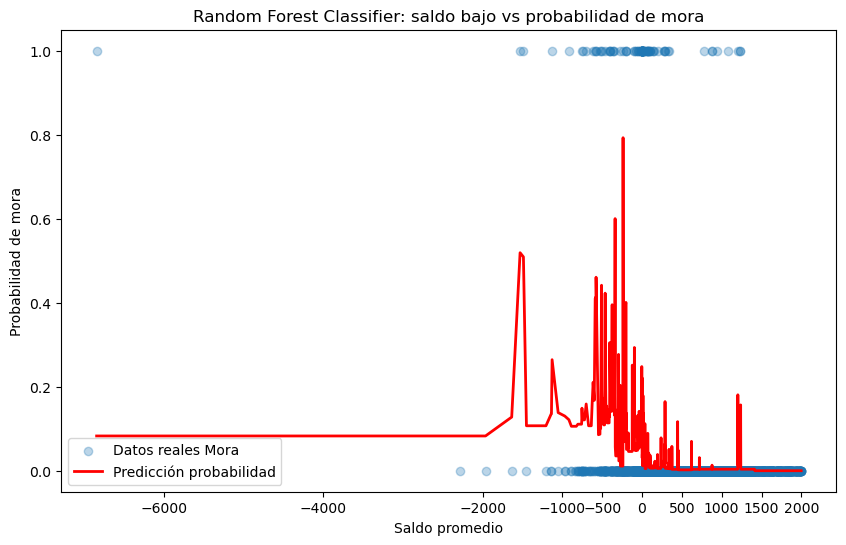

In [45]:
# Ordeno y grafico saldos bajos
X_low_sorted = X_low.sort_values('balance')
y_prob_low_sorted = mejor_rf.predict_proba(X_low_sorted)[:,1]

plt.figure(figsize=(10,6))
plt.scatter(X_low['balance'], y_low, alpha=0.3, label='Datos reales Mora')
plt.plot(X_low_sorted['balance'], y_prob_low_sorted, color='red', linewidth=2, label='Predicción probabilidad')
plt.xticks([-6000,-4000,-2000,-1000,-500,0, 500, 1000, 1500, 2000])  
plt.xlabel("Saldo promedio")
plt.ylabel("Probabilidad de mora")
plt.title("Random Forest Classifier: saldo bajo vs probabilidad de mora")
plt.legend()
plt.show()


In [46]:
#Exporto datos

df_export = pd.DataFrame({
    'balance': X_low_sorted['balance'],
    'probabilidad_mora': y_prob_low_sorted,
    'default_real': y_low.loc[X_low_sorted.index]  
})

# Guardar a CSV
df_export.to_csv("saldo_prob_mora.csv", index=False)
print("Archivo CSV creado con éxito!")


Archivo CSV creado con éxito!


### <span style="color: rgba(230, 0, 126, 1);"> Random Forest Classifier con Balance y Loan</span> ###

In [47]:

df_model = dfA.copy()

# loan a numérico 
if df_model['loan'].dtype == 'object':
    le = LabelEncoder()
    df_model['loan'] = le.fit_transform(df_model['loan'])


#defino variables
X = df_model[['balance', 'loan']]
y = df_model['default_num']

#divido el data set en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

#modelo RF classifier
rf = RandomForestClassifier(random_state=42)

param_grid = {'max_depth': [3,5,7], 'n_estimators':[100,200]}
grid = GridSearchCV(rf, param_grid, cv=3)
grid.fit(X_train, y_train)

# Mejor modelo
mejor_rf = grid.best_estimator_

# Predicciones
y_pred = mejor_rf.predict(X_test)
y_prob = mejor_rf.predict_proba(X_test)[:,1]  # probabilidad de default

# Compruebo calidad del modelo
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC AUC:", roc_auc)

Accuracy: 0.9857885085574573
ROC AUC: 0.9303668127067825


# <span style="color: rgba(230, 0, 126, 1);"> DESAFÍO 3 - MARCOS</span> #

### <span style="color: rgba(230, 0, 126, 1);"> ¿Qué umbrales de saldo pueden indicar mayor riesgo de morosidad? </span> ###

Intentar obtener un modelo predictivo que marque el umbral.
- Regresión logística utilizada para predecir probabilidades de que ocurra un evento binario (por ejemplo, que alguien entre en default o no).
- En nuestro caso:
    - Variable dependiente (Y): Default (0 = no entra en default, 1 = entra en default)
    - Variable independiente (X): Balance (el saldo medio anual del cliente)

Intercepto: [-3.45848994]
Coeficiente balance: [[-0.0020954]]
Balance crítico para p>=0.985: 346.52116642162787


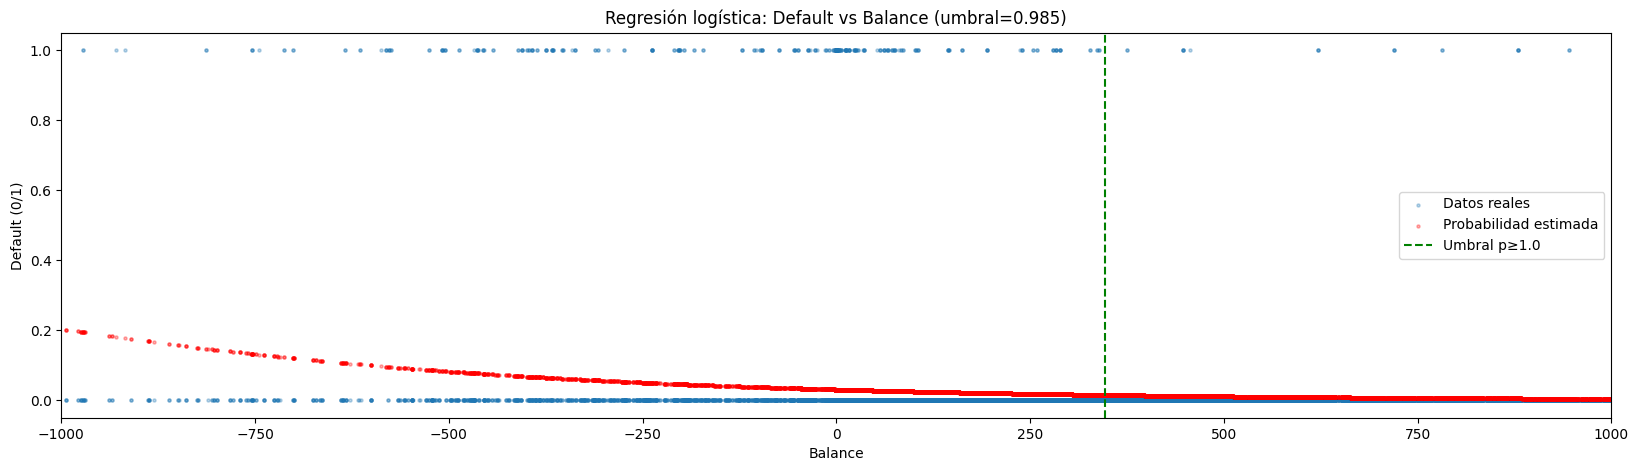

Umbral de balance crítico (p≈0.5): -1650.5130013542203


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar datos
df = pd.read_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\251110_MNG_W03\101125_dataset.csv", sep=";")

# 2. Limpieza de datos
df = df.dropna(subset=['balance', 'default'])
df['balance'] = pd.to_numeric(df['balance'], errors='coerce')

# Convertir default 'yes'/'no' a 0/1 si es necesario
if df['default'].dtype == 'object':
    df['default'] = df['default'].map({'yes': 1, 'no': 0})

# 3. Definir variables
X = df[['balance']]
y = df['default']

# 4. Entrenar modelo
model = LogisticRegression()
model.fit(X, y)

# 5. Mostrar coeficientes
print("Intercepto:", model.intercept_)
print("Coeficiente balance:", model.coef_)

# 6. Calcular probabilidades de default
df['prob_default'] = model.predict_proba(X)[:, 1]

# === 💡 MEJORA: Cambiar umbral ===
umbral = 0.985
y_pred = (df['prob_default'] >= umbral).astype(int)

# Calcular balance crítico (p = umbral)
beta0 = model.intercept_[0]
beta1 = model.coef_[0][0]
balance_critico = -beta0 / beta1 + (np.log((1/umbral) - 1) / beta1)
print(f"Balance crítico para p>={umbral}: {balance_critico}")

# 7. Visualización
plt.figure(figsize=(20,5))
plt.scatter(df['balance'], df['default'], alpha=0.3, label="Datos reales", s=5)
plt.scatter(df['balance'], df['prob_default'], color='red', alpha=0.3, label="Probabilidad estimada", s=5)
plt.xlabel("Balance")
plt.ylabel("Default (0/1)")
plt.title(f"Regresión logística: Default vs Balance (umbral={umbral})")
plt.xlim(-1000, 1000)
plt.axvline(x=balance_critico, color='green', linestyle='--', label=f'Umbral p≥{umbral:.1f}')
plt.legend()
plt.show()

# 8. Calcular umbral de saldo crítico (probabilidad ≈ 50%)
umbral_balance = -beta0 / beta1
print("Umbral de balance crítico (p≈0.5):", umbral_balance)


Iterpretación de los resultados:
- **Intercepto**: -3.45848994
    - representa el punto de partida del modelo cuando el balance es cero. Si una persona tiene un balance de 0, la probabilidad estimada de que entre en default es aproximadamente 3.05%.
     ![image.png](attachment:image.png)
- **Coeficiente balance**: -0.0020954
    - indica cómo cambia la probabilidad de default cuando el balance aumenta en una unidad. Por cada unidad de balance, la probabilidad de default disminuye en 0.0020954, al ser negativa.
- **Balance crítico para p ≥ 0.985**: 542.44
    - indica el punto de balance a partir del cual la probabilidad de default es igual o mayor al 98,5%. Es decir, si el balance de una persona es menor o igual a 542.44, el modelo estima que hay al menos un 99% de probabilidad de que entre en default.
- **Umbral de balance crítico (p≈0.5)**: -1650.51
    - indica el punto de balance a partir del cual la probabilidad de default es igual o mayor al 50%. Es decir, si el balance de una persona es menor o igual a -1650,51, el modelo estima que hay al menos un 50% de probabilidad de que entre en default.

### <span style="color: rgba(230, 0, 126, 1);"> Transformación Finanzas - Power BI </span> ###

In [ ]:
# definir las etiquetas para diferenciar si el cliente tiene algún tipo de préstamo

df['prestamo']=np.where(
    (df.housing=='yes')&(df.loan=='yes'),'housing y loan',
    np.where(
        (df.housing=='yes')&(df.loan=='no'),'housing',
        np.where(
            (df.housing=='no')&(df.loan=='yes'),'loan',
            np.where(
                (df.housing=='no')&(df.loan=='no'),'ninguno',
                'otro'
            )
        )
    )
)

# mover la nueva columna despúes de 'loan'
col='prestamo'
col_ref='loan'  # columna de referencia
cols=list(df.columns)
cols.insert(cols.index(col_ref) + 1, cols.pop(cols.index(col)))
df=df[cols]
df


,id,age,job,marital,education,default,balance,housing,loan,prestamo,...,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group,prob_default
0,1,59.0,administrative,married,secondary,0,2343,yes,no,housing,...,5,may,1042,1,-1,0,unknown,yes,56 - 65,2.321211e-04
1,2,56.0,administrative,married,secondary,0,45,no,no,ninguno,...,5,may,1467,1,-1,0,unknown,yes,56 - 65,2.784713e-02
2,3,41.0,technician,married,secondary,0,1270,yes,no,housing,...,5,may,1389,1,-1,0,unknown,yes,36 - 45,2.194396e-03
3,4,55.0,services,married,secondary,0,2476,yes,no,housing,...,5,may,579,1,-1,0,unknown,yes,46 - 55,1.756735e-04
4,5,54.0,administrative,married,tertiary,0,184,no,no,ninguno,...,5,may,673,2,-1,0,unknown,yes,46 - 55,2.095821e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26171,26383,59.0,administrative,married,secondary,0,3735,no,no,ninguno,...,18,mar,203,4,121,2,failure,yes,56 - 65,1.256202e-05
26172,26384,56.0,management,married,tertiary,0,6798,yes,no,housing,...,17,nov,250,1,-1,0,unknown,no,56 - 65,2.049593e-08
26173,26385,40.0,administrative,single,secondary,0,50,no,no,ninguno,...,15,may,837,1,-1,0,unknown,yes,36 - 45,2.756490e-02
26174,26386,34.0,blue-collar,married,secondary,0,2994,yes,no,housing,...,15,may,358,1,176,1,failure,no,26 - 35,5.934243e-05


In [ ]:
# cálculo de la tasa de mora
totalClientesConMora=len(df[df['default']==1])
print(f'Nº de clientes que tienen deuda:',totalClientesConMora)

totalClientes=len(df)
print(f'Nº de clientes:',totalClientes)

tasaMora=totalClientesConMora/totalClientes
tasaMora=round(tasaMora*100,2)
print(f'Tasa de mora:',tasaMora,'%')

Nº de clientes que tienen deuda: 394
Nº de clientes: 26176
Tasa de mora: 1.51 %


### <span style="color: rgba(230, 0, 126, 1);"> Exportación a csv </span> ###

In [ ]:
df.to_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\251110_MNG_W03\101125_PythonToPowerBI.csv",sep=";",index=False)